# ForecastLab — EXP-003 Data Cleaning

| Informasi | Detail |
|-----------|--------|
| **Project ID** | FL-002 |
| **Eksperimen** | EXP-003 |
| **Dataset** | powerconsumption.csv |
| **Author** | GAKUSEI Najib |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

INPUT_PATH = '../data/powerconsumption.csv'
df = pd.read_csv(INPUT_PATH)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)
print(f'Loaded: {df.shape}')

Loaded: (52416, 9)


In [2]:
print('Missing values:', df.isnull().sum().sum())
print('Duplikat:', df.duplicated().sum())
print(f'Range: {df["Datetime"].min()} s.d. {df["Datetime"].max()}')

Missing values: 0
Duplikat: 0
Range: 2017-01-01 00:00:00 s.d. 2017-12-30 23:50:00


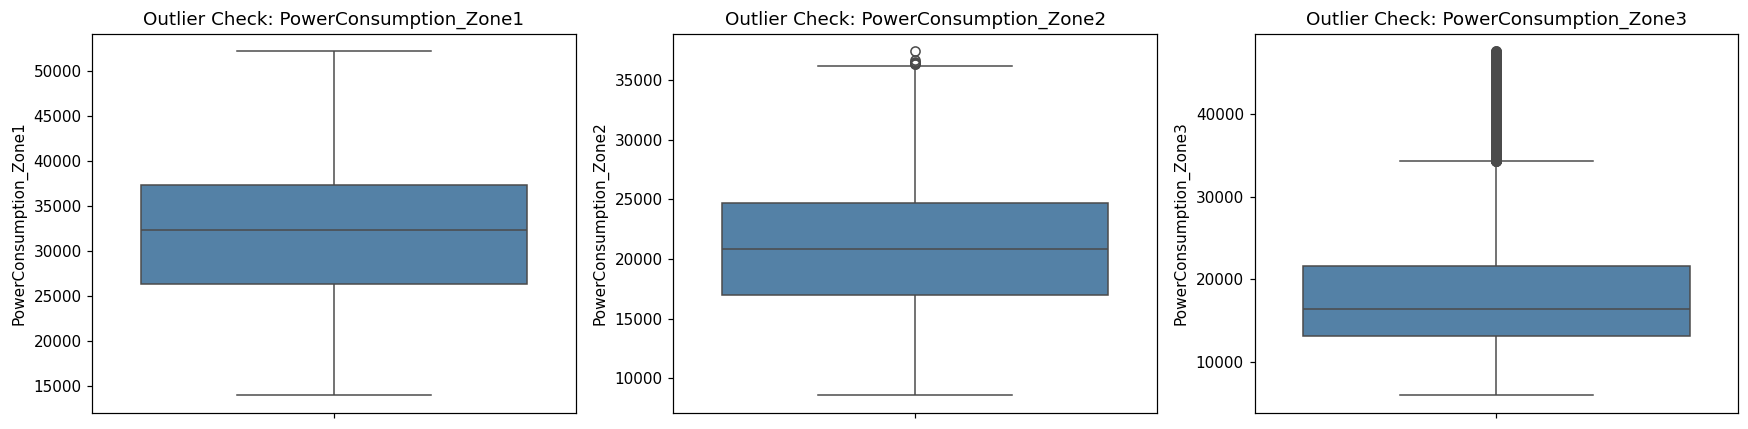

In [3]:
target_cols = ['PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(target_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Outlier Check: {col}')
plt.tight_layout()
plt.savefig('../data/cleaning_01_outlier_boxplot.png', bbox_inches='tight', dpi=110)
plt.show()

In [4]:
df.to_csv('../data/processed_data.csv', index=False)
print('processed_data.csv berhasil disimpan.')

processed_data.csv berhasil disimpan.


---
## Kesimpulan

- Tidak ada missing value atau duplikat
- Terdapat outlier pada target (wajar untuk data time series)
- Dataset sudah bersih dan siap untuk feature engineering

**Next: EXP-004 Feature Engineering**